In [1]:
import scanpy as sc
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.patches import Patch
from matplotlib.ticker import MaxNLocator
import matplotlib.gridspec as gridspec
from matplotlib.patches import Patch
from matplotlib.colors import ListedColormap
from itertools import groupby
import numpy as np
import os
import re
import seaborn as sns
from datetime import datetime
os.environ['TZ'] = 'Europe/Berlin'
import time
time.tzset()

def checkpoint(msg):
    print(f"[{datetime.now().strftime('%Y-%m-%d %H:%M:%S')}] {msg}", flush=True)

In [2]:

OUT_DIR = "/net/bq-storage/ag-cherrmann/bq_cinac/projects/synimmune/results/08_TICAtlas"
os.makedirs(OUT_DIR, exist_ok=True)
BASE = "/net/bq-storage/ag-cherrmann/bq_cinac/projects/synimmune"
adata = sc.read_h5ad(f"{BASE}/data/01_extGBmap/immune_cells_gbmap_TICAannot_gpu.h5ad")
mp_scores = pd.read_csv(f"{BASE}/results/04_NMF_GSEAonHGNC/04_3_nmf_all_gsea_c7/mp_scores.csv", index_col=0)


In [8]:
print(mp_scores.head())

            MP1_score  MP2_score  MP3_score  MP4_score  MP5_score  MP6_score  \
PJ017_2-0   -0.175999  -0.252572  -0.297089  -0.113884  -0.236565   0.115818   
PJ017_16-0  -0.113179  -0.150775  -0.038705  -0.211535  -0.472807  -0.138351   
PJ017_17-0  -0.164964  -0.234958   1.228976   0.417442   0.273041   0.394193   
PJ017_34-0  -0.147234  -0.205894   0.274334  -0.195601  -0.316003   0.005004   
PJ017_40-0  -0.159795  -0.192466  -0.072902  -0.181600  -0.415498   0.016681   

            MP7_score  MP8_score  MP9_score  MP10_score  ...  MP21_score  \
PJ017_2-0   -0.005583   0.013826   0.559257    0.781599  ...    1.447125   
PJ017_16-0  -0.098880   0.001727  -0.007214   -0.904169  ...   -0.343193   
PJ017_17-0   0.109770   0.175236   0.256457    1.904633  ...   -0.232244   
PJ017_34-0   0.015723   0.051400   0.343743    0.491191  ...    0.941769   
PJ017_40-0  -0.009934   0.036377   0.261621   -0.650518  ...    0.177680   

            MP22_score  MP23_score  MP24_score  MP25_score  MP

In [14]:
import pyreadr

result = pyreadr.read_r("/net/bq-storage/ag-cherrmann/bq_cinac/projects/synimmune/data/cell_type_palette.rds")
df = result[None]
# print(df)

In [3]:
SELECTED_MPS = ["MP1", "MP2", "MP7", "MP8", "MP9", "MP11", "MP14", "MP15", "MP19", "MP20"]

In [4]:
celltype_palette = {
    "B cells":                     "#5A5156",
    "B cells proliferative":       "#E4E1E3",
    "Plasma B cells":              "#F6222E",
    "T cells naive":               "#FE00FA",
    "T cells regulatory":          "#16FF32",
    "T helper cells":              "#3283FE",
    "CD4 effector memory":         "#FEAF16",
    "T cells proliferative":       "#B00068",
    "CD4 recently activated":      "#1CFFCE",
    "CD4 naive-memory":            "#90AD1C",
    "CD4 transitional memory":     "#2ED9FF",
    "CD8 pre-exhausted":           "#DEA0FD",
    "CD8 cytotoxic":               "#AA0DFE",
    "CD8 effector memory":         "#F8A19F",
    "CD8 terminally exhausted":    "#325A9B",
    "NK":                          "#C4451C",
    "Macrophages SPP1":            "#1C8356",
    "TAMs C1QC":                   "#85660D",
    "TAMs proinflammatory":        "#B10DA1",
    "Macro. and mono. prolif.":    "#FBE426",
    "Monocytes":                   "#1CBE4F",
    "cDC":                         "#822E1C",
    "pDC":                         "#333333",
    "mDC":                         "#F7E1A0",
    "Mast cells":                  "#C075A6",
}

current_cats = set(adata.obs["decoupler_level1_celltype"].cat.categories)
assert set(celltype_palette.keys()) == current_cats, (
    f"Mismatch — missing: {current_cats - set(celltype_palette.keys())}, "
    f"extra: {set(celltype_palette.keys()) - current_cats}"
)
adata.obs["decoupler_level1_celltype"] = adata.obs["decoupler_level1_celltype"].cat.reorder_categories(list(celltype_palette.keys()))



In [16]:
print(adata.obs.columns.tolist())

['author', 'donor_id', 'assay_ontology_term_id', 'cell_type_ontology_term_id', 'development_stage_ontology_term_id', 'disease_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'is_primary_data', 'sex_ontology_term_id', 'annotation_level_1', 'annotation_level_2', 'annotation_level_3', 'gbmap', 'suspension_type', 'stage', 'location', 'sector', 'celltype_original', 'EGFR', 'MET', 'p53', 'TERT', 'ATRX', 'PTEN', 'MGMT', 'chr1p19q', 'PDGFR', 'tissue_ontology_term_id', 'tissue_type', 'cell_type', 'assay', 'disease', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid', 'decoupler_level1_celltype', 'decoupler_level1_score', 'decoupler_level2_celltype', 'decoupler_level2_score', 'MP1_score', 'MP2_score', 'MP3_score', 'MP4_score', 'MP5_score', 'MP6_score', 'MP7_score', 'MP8_score', 'MP9_score', 'MP10_score', 'MP11_score', 'MP12_score', 'MP13_score', 'MP14_score', 'MP15_score', 'MP16_score', 'MP17_score', 'MP18_score', 'MP19_score', 'MP20_score', 'MP2

### assign selected MP scores to adata.obs

In [5]:
for col in mp_scores.columns:
    if col not in adata.obs.columns:
        adata.obs[col] = mp_scores[col].reindex(adata.obs_names).values

adata.obs["decoupler_level1_celltype"] = adata.obs["decoupler_level1_celltype"].cat.reorder_categories(list(celltype_palette.keys()))

mp_score_cols = [mp + "_score" for mp in SELECTED_MPS if f"{mp}_score" in adata.obs.columns]
missing_mps = [mp for mp in SELECTED_MPS if f"{mp}_score" not in mp_scores.columns]
if missing_mps:
    checkpoint(f"WARNING: {len(missing_mps)} selected MPs not found in mp_scores.columns: {missing_mps}")

checkpoint(f"Plotting {len(mp_score_cols)} selected MP score columns")

[2026-09-14 11:17:31] Plotting 10 selected MP score columns


### Violin plot grid: significant MP with mp score for each TICA celltype

[2026-09-12 12:33:19] Plotting 10 selected MP score columns


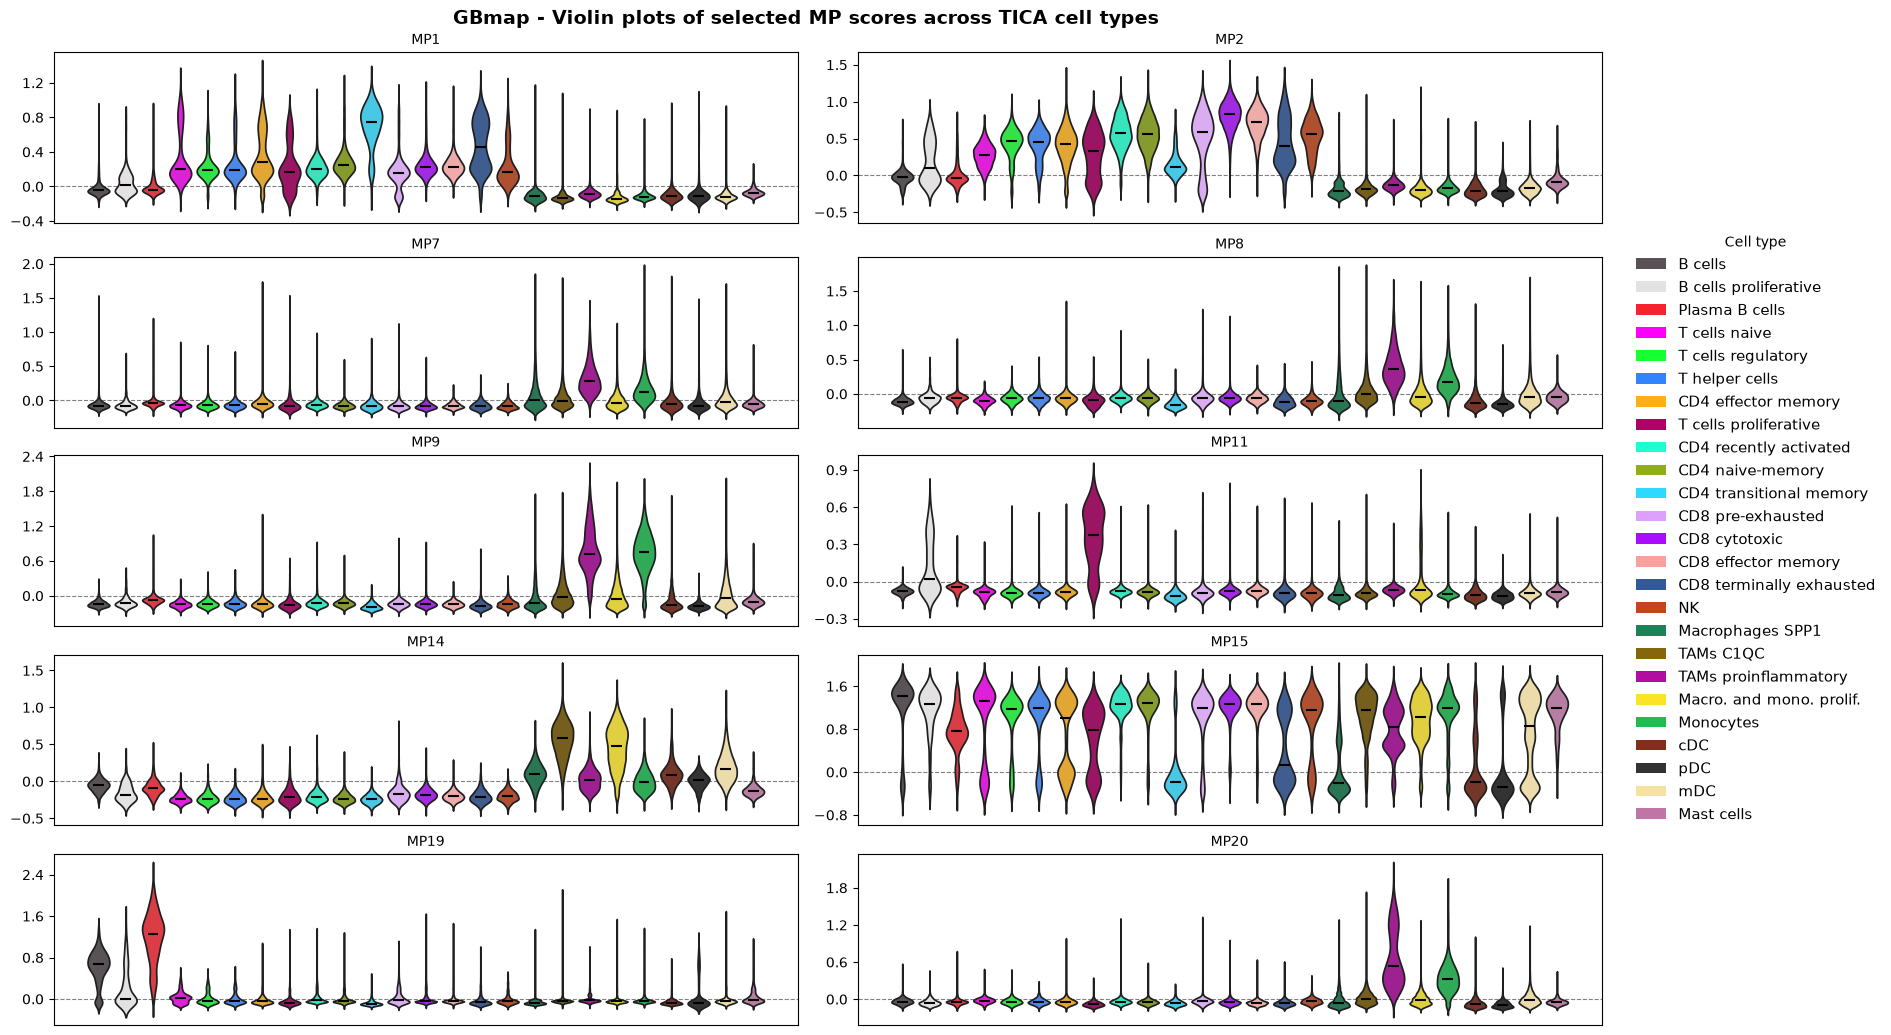

[2026-09-12 12:34:07] Combined PDF with all MP violin plots saved


In [ ]:


n_mps = len(mp_score_cols)
n_cols = 2
n_rows = -(-n_mps // n_cols)  # ceil division

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 8, n_rows * 2), constrained_layout=True)
axes = axes.flatten()

for i, mp_col in enumerate(mp_score_cols):
    mp_name = mp_col.replace("_score", "")
    sns.violinplot(
        data=adata.obs,
        x="decoupler_level1_celltype",
        y=mp_col,
        hue="decoupler_level1_celltype",
        palette=celltype_palette,
        order=list(celltype_palette.keys()),
        legend=False,
        ax=axes[i],
        inner=None,
    )
    medians = adata.obs.groupby("decoupler_level1_celltype", observed=True)[mp_col].median()
    medians = medians.reindex(celltype_palette.keys())
    for x_pos, med_val in enumerate(medians):
        axes[i].hlines(med_val, x_pos - 0.2, x_pos + 0.2, colors="black", linewidth=1.5, zorder=3)

    axes[i].set_title(mp_name, fontsize=10)
    axes[i].set_xlabel("")
    axes[i].set_ylabel("")
    axes[i].set_xticks([])
    axes[i].axhline(0, color="grey", linestyle="--", linewidth=0.8, zorder=0)
    axes[i].yaxis.set_major_locator(MaxNLocator(nbins=5))


for j in range(n_mps, len(axes)):
    axes[j].axis("off")



legend_handles = [Patch(facecolor=color, label=ct) for ct, color in celltype_palette.items()]
fig.legend(handles=legend_handles, loc="center left", bbox_to_anchor=(1.01, 0.5),fontsize=11, title="Cell type", frameon=False)
fig.suptitle("GBmap - Violin plots of selected MP scores across TICA cell types", fontsize=14, y=1.02, fontweight="bold")
plt.savefig(os.path.join(OUT_DIR, "08_09_violin_sign_MPs_per_celltype.pdf"), dpi=300, bbox_inches="tight")
plt.show()
plt.close()
checkpoint("Combined PDF with all MP violin plots saved")



### "Marker-Gene × Top-Scoring-Cells"-Heatmap 

In [6]:
genes = pd.read_csv(f"{BASE}/results/04_NMF_GSEAonHGNC/04_3_nmf_all_gsea_c7/genes.csv")

In [20]:
print(genes.head())

     gene   mp     score
0   SKAP1  MP1  0.012087
1    CD96  MP1  0.008915
2     FYN  MP1  0.008811
3  THEMIS  MP1  0.008810
4   CD247  MP1  0.007919


In [7]:
n_top_genes = 5
n_top_cells = 500

# choose top 5 marker genes per MP

top_genes_per_mp = {}
for mp in SELECTED_MPS:
    sub = genes[genes["mp"] == mp].sort_values("score", ascending=False)
    top_genes_per_mp[mp] = sub["gene"].head(n_top_genes).tolist()

row_genes = [] # save in dict
row_mp_labels = []
for mp in SELECTED_MPS:
    for g in top_genes_per_mp[mp]:
        row_genes.append(g)
        row_mp_labels.append(mp)

# choose top 500 cells per MP

selected_cells = []
cell_mp_labels = []
for mp in SELECTED_MPS:
    scores = mp_scores[mp+"_score"]
    threshold = scores.quantile(0.75)
    top_cells = scores[scores >= threshold].sort_values(ascending=False)
    top_cells = top_cells.head(n_top_cells)
    selected_cells.extend(top_cells.index.tolist())
    cell_mp_labels.extend([mp] * len(top_cells))

# sort cells first by MP, then score

cell_order_df = pd.DataFrame({"cell": selected_cells, "mp": cell_mp_labels})
cell_order_df["score"] = [
    mp_scores.loc[c, mp+"_score"] for c, mp in zip(cell_order_df["cell"], cell_order_df["mp"])
]
cell_order_df["mp"] = pd.Categorical(cell_order_df["mp"], categories=SELECTED_MPS, ordered=True)
cell_order_df = cell_order_df.sort_values(["mp", "score"], ascending=[True, False])
cell_order_df = cell_order_df.drop_duplicates(subset="cell", keep="first")

# extract final order

ordered_cells = cell_order_df["cell"].tolist()
ordered_cell_mps = cell_order_df["mp"].tolist()
ordered_cell_types = adata.obs.loc[ordered_cells, "decoupler_level1_celltype"].tolist()

# extract expression matrix
expr = adata[ordered_cells, row_genes].X
if not isinstance(expr, np.ndarray):
    expr = expr.toarray()
expr_df = pd.DataFrame(expr.T, index=row_genes, columns=ordered_cells)

# Z-score normalization per gene

expr_z = expr_df.sub(expr_df.mean(axis=1), axis=0).div(expr_df.std(axis=1), axis=0)
expr_z = expr_z.clip(-2.5, 2.5)

mp_colors = dict(zip(SELECTED_MPS, plt.cm.tab10.colors[:len(SELECTED_MPS)]))

/tmp/ipykernel_3999323/3399860199.py:62: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.8, 0.97])


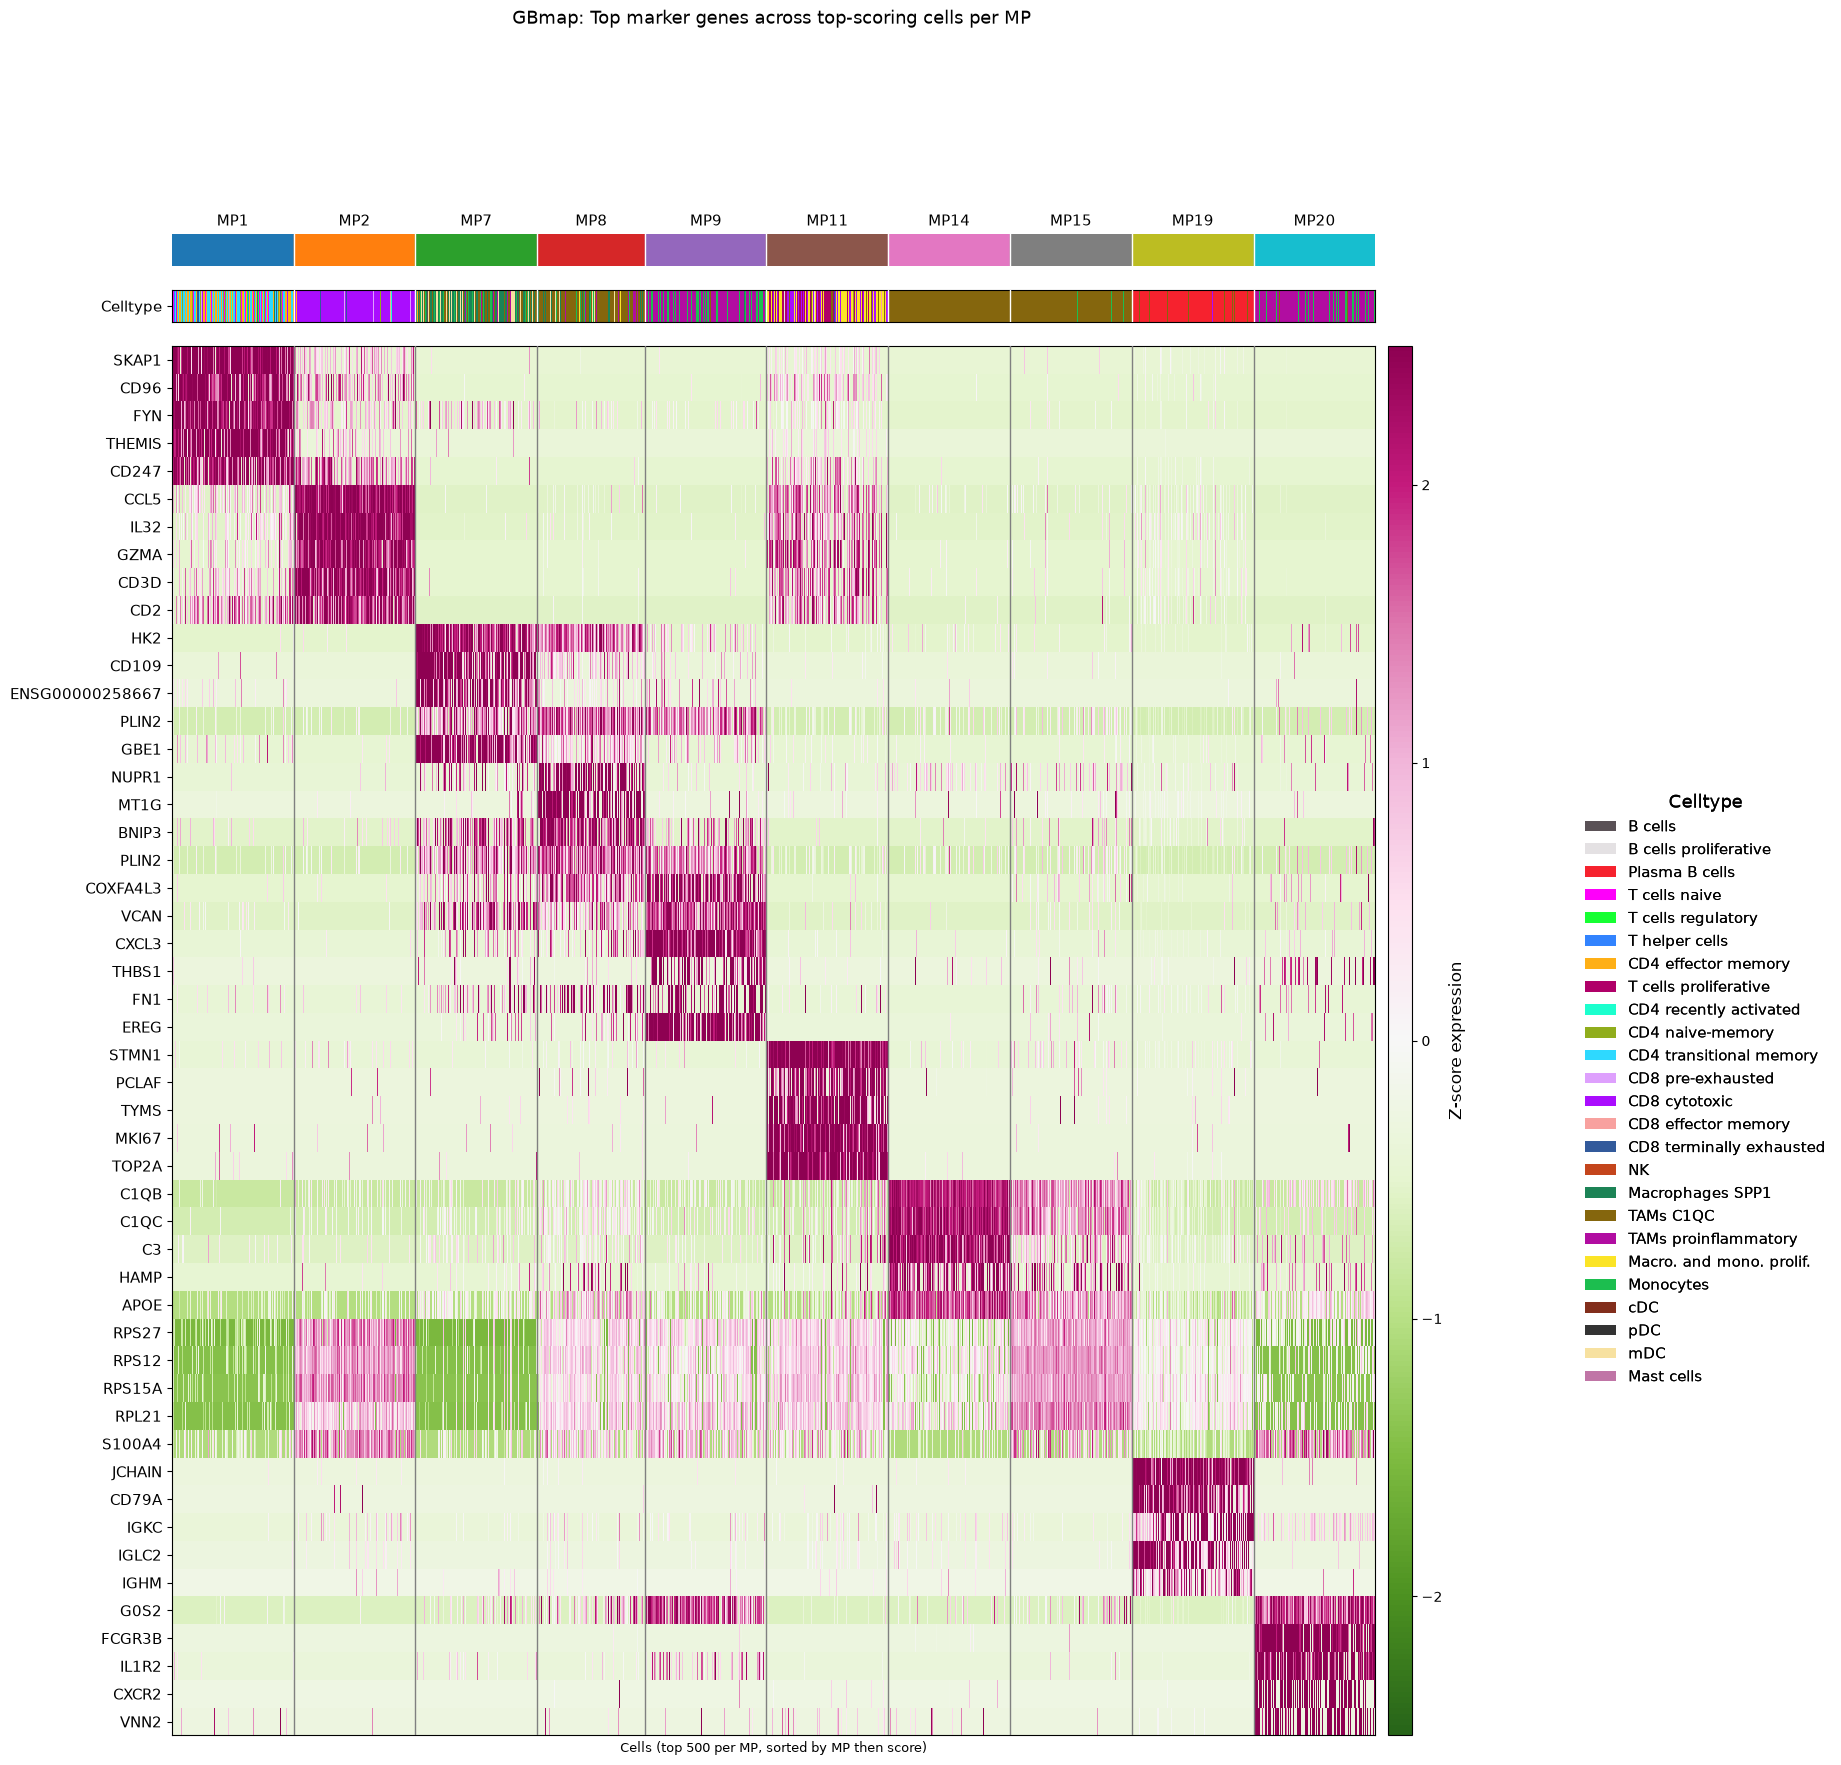

In [21]:
fig = plt.figure(figsize=(16, len(row_genes) * 0.35 + 2))
gs = gridspec.GridSpec(3, 2, height_ratios=[0.4, 0.4, len(row_genes) * 0.35], width_ratios=[1, 0.02], hspace=0.05, wspace=0.02)

ax_mp = fig.add_subplot(gs[0, 0])
ax_ct = fig.add_subplot(gs[1, 0], sharex=ax_mp)
ax_hm = fig.add_subplot(gs[2, 0], sharex=ax_mp)
ax_cbar = fig.add_subplot(gs[2, 1])


ax_mp.imshow([range(len(ordered_cells))], aspect="auto",
             cmap=ListedColormap([mp_colors[mp] for mp in SELECTED_MPS]),
             extent=[0, len(ordered_cells), 0, 1], interpolation="none")
ax_mp.set_yticks([]); ax_mp.set_xticks([])
for spine in ax_mp.spines.values():
    spine.set_visible(False)

segment_info = []
pos = 0
for mp, group in groupby(ordered_cell_mps):
    length = len(list(group))
    segment_info.append((mp, pos, pos + length))
    pos += length

for mp, start, end in segment_info:
    ax_mp.axvspan(start, end, color=mp_colors[mp])
    center = (start + end) / 2
    ax_mp.text(center, 1.15, mp, ha="center", va="bottom", fontsize=11)

for mp, start, end in segment_info[:-1]:
    ax_hm.axvline(end, color="grey", linewidth=1, zorder=3)
    ax_mp.axvline(end, color="white", linewidth=1, zorder=3)
    ax_ct.axvline(end, color="white", linewidth=1, zorder=3)

ct_categories = list(celltype_palette.keys())
ct_to_idx = {ct: i for i, ct in enumerate(ct_categories)}
ct_indices = [ct_to_idx[ct] for ct in ordered_cell_types]
ax_ct.imshow([ct_indices], aspect="auto",
             cmap=ListedColormap([celltype_palette[ct] for ct in ct_categories]),
             vmin=0, vmax=len(ct_categories) - 1,
             extent=[0, len(ordered_cells), 0, 1], interpolation="none")
ax_ct.set_yticks([0.5]); ax_ct.set_yticklabels(["Celltype"], fontsize=11)
ax_ct.set_xticks([])

im = ax_hm.imshow(expr_z.values, aspect="auto", cmap="PiYG_r",
                   vmin=-2.5, vmax=2.5, interpolation="none")
ax_hm.set_yticks(range(len(row_genes)))
ax_hm.set_yticklabels(row_genes, fontsize=11)
ax_hm.set_xticks([])
ax_hm.set_xlabel(f"Cells (top {n_top_cells} per MP, sorted by MP then score)", fontsize=9)


cbar = fig.colorbar(im, cax=ax_cbar)
cbar.set_label("Z-score expression", fontsize=12)

ct_handles = [Patch(facecolor=celltype_palette[ct], label=ct) for ct in ct_categories]

leg = fig.legend(handles=ct_handles, loc="upper left", bbox_to_anchor=(1.0, 0.6), fontsize=11, title="Celltype", frameon=False, ncol=1)
leg.get_title().set_fontsize(13)
fig.add_artist(leg)

fig.suptitle("GBmap: Top marker genes across top-scoring cells per MP", fontsize=13, y=0.995)
plt.tight_layout(rect=[0, 0, 0.8, 0.97])
plt.savefig(os.path.join(BASE, "results", "08_TICAtlas", "08_09_heatmap_mp_genes_cells.pdf"), bbox_inches="tight", dpi=300)
plt.show()
plt.close()

In [71]:
cell_order_df[cell_order_df["mp"] == "MP8"].shape[0]

444

In [73]:
scores = mp_scores["MP8_score"]
threshold = scores.quantile(0.75)
(scores >= threshold).sum()

np.int64(158428)

In [34]:
top_genes_per_mp["MP7"][2]

'ENSG00000258667'

## Heatmap cells vs MP

In [6]:
celltype_col = "decoupler_level1_celltype"
mp_cols = [f"{mp}_score" for mp in SELECTED_MPS]

checkpoint(f"MP score columns ({len(mp_cols)}): {mp_cols}")

valid_cells = (
    adata.obs[mp_cols].notna().all(axis=1)
    & adata.obs[celltype_col].notna()
)

heatmap_obs = adata.obs.loc[valid_cells, [celltype_col] + mp_cols].copy()

checkpoint(f"Cells included in heatmap: {heatmap_obs.shape[0]}/{adata.n_obs}")

# Reihenfolge entspricht exakt der Reihenfolge im Dictionary
celltype_order = list(celltype_palette.keys())
checkpoint(f"Celltype order from palette: {celltype_order}")


heatmap_obs[celltype_col] = pd.Categorical(
    heatmap_obs[celltype_col].astype(str),
    categories=celltype_order,
    ordered=True,
)

# Pro Zelle: MP mit höchstem Score unter den SELECTED_MPS
heatmap_obs["dominant_mp"] = heatmap_obs[mp_cols].idxmax(axis=1)
heatmap_obs["dominant_mp_score"] = heatmap_obs[mp_cols].max(axis=1)

dominant_mp_order = [f"{mp}_score" for mp in SELECTED_MPS]
heatmap_obs["dominant_mp"] = pd.Categorical(
    heatmap_obs["dominant_mp"],
    categories=dominant_mp_order,
    ordered=True,
)

heatmap_obs = heatmap_obs.sort_values(
    by=[celltype_col, "dominant_mp", "dominant_mp_score"],
    ascending=[True, True, False],
)

mp_matrix = heatmap_obs[mp_cols].copy()
mp_matrix_plot = (
    mp_matrix - mp_matrix.min(axis=0)
).div(
    (mp_matrix.max(axis=0) - mp_matrix.min(axis=0)).replace(0, 1),
    axis=1,
)
row_colors = heatmap_obs[celltype_col].astype(str).map(celltype_palette)

n_missing = row_colors.isna().sum()
if n_missing > 0:
    checkpoint(f"WARNING: {n_missing} Zellen ohne Farbzuordnung — Namen prüfen: "
               f"{set(heatmap_obs[celltype_col].astype(str)) - set(celltype_palette.keys())}")

[2026-09-14 11:17:31] MP score columns (10): ['MP1_score', 'MP2_score', 'MP7_score', 'MP8_score', 'MP9_score', 'MP11_score', 'MP14_score', 'MP15_score', 'MP19_score', 'MP20_score']
[2026-09-14 11:17:31] Cells included in heatmap: 633710/633710
[2026-09-14 11:17:31] Celltype order from palette: ['B cells', 'B cells proliferative', 'Plasma B cells', 'T cells naive', 'T cells regulatory', 'T helper cells', 'CD4 effector memory', 'T cells proliferative', 'CD4 recently activated', 'CD4 naive-memory', 'CD4 transitional memory', 'CD8 pre-exhausted', 'CD8 cytotoxic', 'CD8 effector memory', 'CD8 terminally exhausted', 'NK', 'Macrophages SPP1', 'TAMs C1QC', 'TAMs proinflammatory', 'Macro. and mono. prolif.', 'Monocytes', 'cDC', 'pDC', 'mDC', 'Mast cells']


In [7]:
MP_PALETTE = {
    "MP1":  "#ff006e", "MP2":  "#8338ec", "MP7":  "#c9184a", "MP8":  "#fb8500",
    "MP9":  "#ffb703", "MP11": "#d00000", "MP14": "#9d4edd", "MP15": "#ff4d6d",
    "MP19": "#f77f00", "MP20": "#ffd60a",
}
col_colors = pd.Series(
    [MP_PALETTE[mp] for mp in SELECTED_MPS],
    index=mp_cols,
    name="Metaprogram",
)


g = sns.clustermap(
    mp_matrix_plot,
    row_cluster=False,
    col_cluster=False,
    row_colors=row_colors,
    col_colors=col_colors,
    cmap="inferno",
    yticklabels=False,
    xticklabels=SELECTED_MPS,
    figsize=(16, 14),
    cbar_pos=None,
    dendrogram_ratio=(0.001, 0.001),
    colors_ratio=0.02,
    linewidths=0,
)

pos_row = g.ax_row_colors.get_position()
pos_col = g.ax_col_colors.get_position()

gap = 0.03

g.ax_row_colors.set_position([pos_row.x0 - gap, pos_row.y0, pos_row.width, pos_row.height])
g.ax_col_colors.set_position([pos_col.x0, pos_col.y0 + gap, pos_col.width, pos_col.height])
pos_hm = g.ax_heatmap.get_position()
g.ax_heatmap.set_position([pos_hm.x0 + gap, pos_hm.y0, pos_hm.width - gap, pos_hm.height - gap])

g.fig.subplots_adjust(right=0.72, top=0.92)

g.ax_heatmap.set_xlabel("")
g.ax_heatmap.set_ylabel("")
g.ax_heatmap.set_xticklabels([])
g.ax_heatmap.tick_params(axis="x", length=0)

g.ax_row_colors.set_xlabel("Celltype", fontsize=10)
g.ax_col_colors.set_ylabel("MP", fontsize=10, rotation=0, ha="right", va="center")  # Label für die neue Leiste
g.ax_col_colors.set_xticks(np.arange(len(mp_cols)) + 0.5)
g.ax_col_colors.set_xticklabels(SELECTED_MPS, fontsize=10, rotation=0)
g.ax_col_colors.xaxis.set_ticks_position("top")
g.ax_col_colors.xaxis.set_label_position("top")
g.ax_col_colors.tick_params(axis="x", pad=2, length=0)  # length=0: keine Tick-Striche, nur Text

# "Celltype"-Beschriftung an der row_colors-Leiste
g.ax_row_colors.set_xlabel("Celltype", fontsize=10)
g.ax_col_colors.set_ylabel("MP", fontsize=10, rotation=0, ha="right", va="center")

g.fig.suptitle(
    "Selected MP scores across GBMAP cells",
    y=1.02, fontsize=14, fontweight="bold",
)

mappable = g.ax_heatmap.collections[0]
cax = g.fig.add_axes([0.78, 0.05, 0.03, 0.15])  # unten rechts, wie gewünscht
cbar = g.fig.colorbar(mappable, cax=cax)
cbar.set_label("MP score", fontsize=10)

ct_handles = [Patch(facecolor=celltype_palette[ct], label=ct) for ct in celltype_order]
leg1 = g.fig.legend(
    handles=ct_handles, loc="upper left", bbox_to_anchor=(0.73, 0.9), fontsize=9, title="Celltype", frameon=False, ncol=1)
leg1.get_title().set_fontsize(11)

out_pdf = os.path.join(OUT_DIR, "08_09_heatmap_cells_vs_MP_by_celltype.pdf")

g.fig.savefig(out_pdf, bbox_inches="tight", dpi=300)
# plt.show()
plt.close(g.fig)

checkpoint(f"Saved: {out_pdf}")

[2026-09-14 11:24:08] Saved: /net/bq-storage/ag-cherrmann/bq_cinac/projects/synimmune/results/08_TICAtlas/08_09_heatmap_cells_vs_MP_by_celltype.pdf
